<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Controls/E_20_194_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 1**

## Twin Rotor System Dynamics

The kinematics and dynamics of the twin rotor system can be modeled by the following equations:

$$
\begin{aligned}
\dot{R} &= \widehat{\omega}R, & (1) \\
\dot{\pi} &= \tau^e + \tau^u, & (2)
\end{aligned}
$$

where the angular velocity $\omega$ is related to the angular momentum $\pi$ via the rotational inertia tensor $\mathbb{I}^R$:

$$
\omega = (\mathbb{I}^R)^{-1}\pi, \quad (3)
$$

### Control Moments
The manipulatable (control) moments $\tau^u$ are split from the unmanipulatable parts and take the form:

$$
\tau^u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix}
\begin{bmatrix} \cos \alpha & -\cos \beta \\ \sin \alpha & -\sin \beta \end{bmatrix}
\begin{bmatrix} u_1 \\ u_2 \end{bmatrix}
$$

### Constraint Moments
The constraint moment $\tau^e$ prevents the rotation of the device about the $\mathbb{b}_2$ axis and is defined as:

$$
\tau^e = R \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}, \quad (4)
$$

where the scalar component $T_2$ is given by:

$$
T_2 = e_2^T \left( \Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega} \right) \quad (5)
$$

and $\Omega = R^T\omega$ represents the angular velocity in the body-fixed frame.

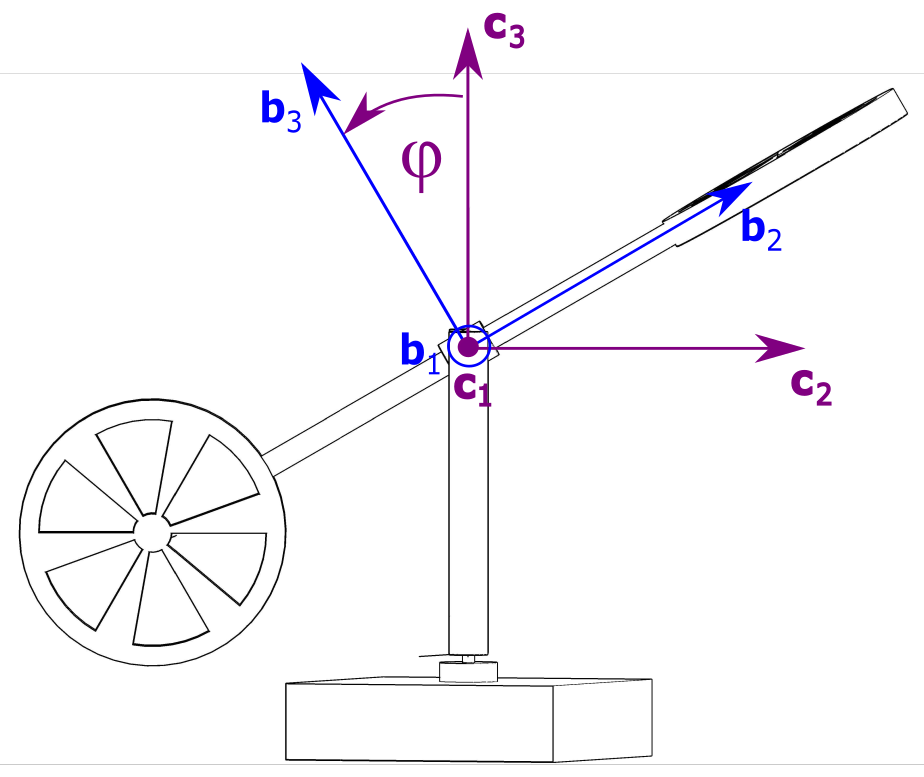

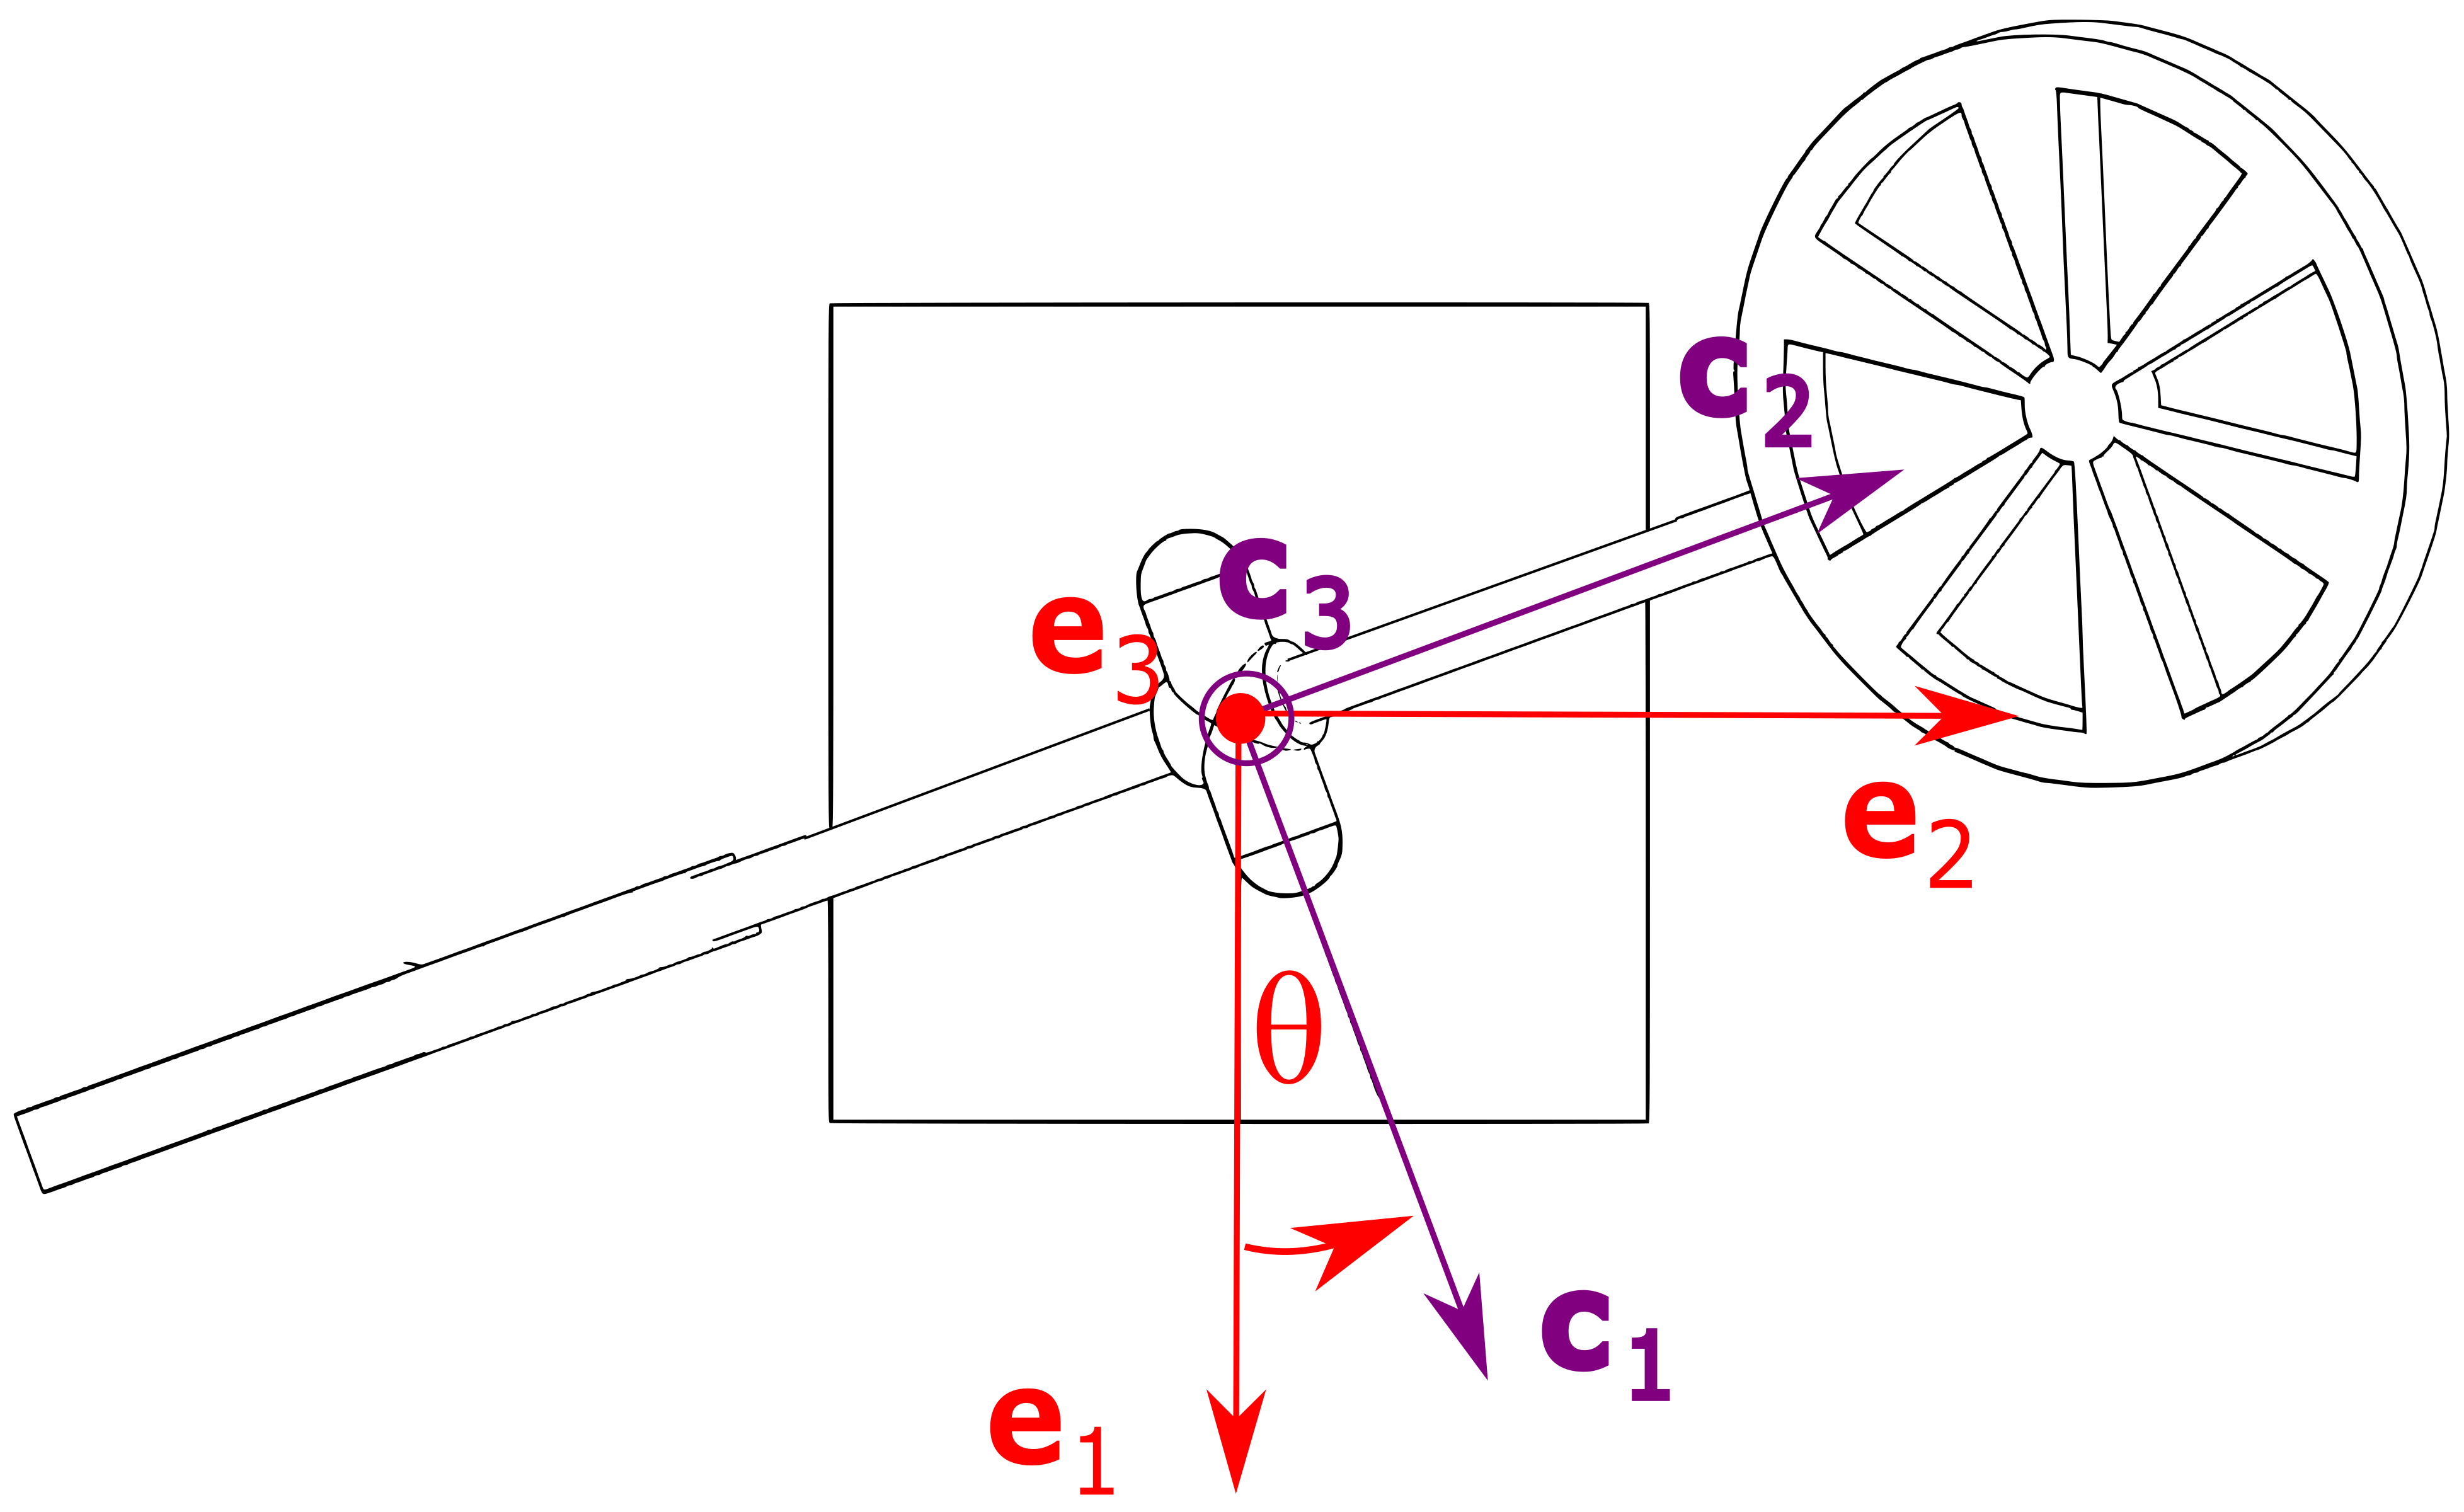

**TASK 2**

##Install Simulation Library

In [ ]:
# Install simulation helpers (Run this cell first)
!pip install --quiet git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


##Imports & Initialization

In [ ]:
import numpy as np
from numpy import linalg
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
import plotly.graph_objects as go
import plotly.express as px
import sims

init_vprinting()

mr = sims.RigidBodySim()


##External Force Model

In [ ]:
def externalForceModel(qq, parameters, X):
    fe = np.array([0, 0, 0])
    taue = np.array([0, 0, 0])
    return [taue, fe]

mr.set_external_force_model(externalForceModel)


##Reference Configuration

In [ ]:
def referenceConfig(qq, II, t):

    dotOmegart = np.array([0., 0., 0.])
    dotPir = II @ dotOmegart

    Omegart = np.array([1, 0, 1])   # Constant reference
    Pir = II @ Omegart

    theta = linalg.norm(Omegart)*t + 0.2*np.pi
    nOmega = Omegart/(0.000001 + linalg.norm(Omegart))

    qOmega = np.concatenate(([np.cos(theta/2)],
                             np.sin(theta/2)*nOmega))

    Rr = qq.r_from_quaternions(qOmega)

    return [Rr, Pir, dotPir]


##Controller


In [ ]:
def controller(qq, parameters, t, X, taue, fe):

    II = parameters['II']

    R = X[0][0]
    omega = X[1]
    piI = X[3]

    Rr, Pir, dotPir = referenceConfig(qq, II, t)

    pir = Rr @ Pir
    omegar = Rr @ linalg.inv(II) @ Pir

    Re = Rr @ R.T

    pie = R @ II @ Rr.T @ (omegar - Re @ omega)

    K = np.array([[1,0,0],
                  [0,2,0],
                  [0,0,3]])

    eRhat = 0.5*(Re @ K - K @ Re.T)

    eR = np.array([
        -eRhat[1,2],
         eRhat[0,2],
        -eRhat[0,1]
    ])

    tauu_nom = (R @ dotPir +
                qq.hat_matrix(omega) @ pir) \
               - taue \
               + (4*eR + 10*pie + 2*piI)

    Tu_nom = R.T @ tauu_nom

    u_minus = np.sqrt(Tu_nom[0]**2 + Tu_nom[2]**2)
    alpha = np.atan2(Tu_nom[2], Tu_nom[0])

    tauu = R @ np.array([
        u_minus*np.cos(alpha),
        0,
        u_minus*np.sin(alpha)
    ])

    fu = -fe + np.array([0,0,0])

    return [tauu, fu, eR, pie]


##Actuator Wrapper

In [ ]:
def actuator(qq, parameters, t, X, taue, fe):
    Uc = controller(qq, parameters, t, X, taue, fe)
    tauu = Uc[0]
    fu = Uc[1]
    return [tauu, fu]

mr.set_actuator(actuator)


##System Parameters

In [ ]:
cubeDimensions = {
    'l':4,
    'w':2,
    'h':1,
    'xp':2.,
    'yp':1.,
    'zp':0.5
}

II = np.diag([1.0, 1.2, 1.5])

parameters = {
    'CM': np.array([
        cubeDimensions['l']/2 - cubeDimensions['xp'],
        cubeDimensions['w']/2 - cubeDimensions['yp'],
        cubeDimensions['h']/2 - cubeDimensions['zp']
    ]),
    'II': II,
    'M': 1.0,     # REQUIRED
    'g': 9.81     # REQUIRED
}

##Controller Integral Dynamics

In [ ]:
def controller_dynamics(qq, t, X, taue, fe, parameters):
    Uc = controller(qq, parameters, t, X, taue, fe)
    eR = Uc[2]
    return eR


##System Parameters

In [ ]:
cubeDimensions = {
    'l':4,
    'w':2,
    'h':1,
    'xp':2.,
    'yp':1.,
    'zp':0.5
}

II = np.diag([1.0, 1.2, 1.5])

parameters = {
    'CM': np.array([
        cubeDimensions['l']/2 - cubeDimensions['xp'],
        cubeDimensions['w']/2 - cubeDimensions['yp'],
        cubeDimensions['h']/2 - cubeDimensions['zp']
    ]),
    'II': II
}


##Initial Conditions

In [ ]:
ICq = mr.q_from_axis_angles(0., np.array([1,0,0]))
ICR = mr.r_from_quaternions(ICq)

ICOmega = np.array([0.,0.,0.])
ICo = np.array([0.,0.,0.])
ICp = np.array([0.,0.,0.])
ICXC = np.array([0.,0.,0.])

ICs = [
    [ICR, ICo],
    ICR @ ICOmega,
    ICp,
    ICXC
]


##Run Simulation

In [ ]:
sim_data = mr.simulating_a_cube(
    0.1,      # timestep
    50.,      # total time
    cubeDimensions,
    parameters,
    ICs
)

fig = mr.animated_cube_flat_shading(
    sim_data,
    'Twin Rotor Attitude Tracking'
)

fig
